<a href="https://colab.research.google.com/github/Alessandro-json/AI_PostProcessing_Detection/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

# Imports

In [ ]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image


# Globals


In [ ]:
# Choose where the project will be stored in Colab.
WORKDIR = Path('/content')

REPO_URL = 'https://github.com/Alessandro-json/AI_PostProcessing_Detection'

# Repository folder name after git clone.
REPO_DIR = WORKDIR / 'REPO'

# Main paths used by the scripts.
TRAIN_CSV = 'data/splits/train_balanced.csv'
VAL_CSV = 'data/splits/val_balanced.csv'
TEST_CSV = 'data/splits/test_balanced.csv'

IMAGE_ROOT = "/content/data/raw/RRDataset_subset"
CHECKPOINT_NAME = 'best_rgb.pt'
CHECKPOINT_PATH = f'checkpoints/{CHECKPOINT_NAME}'
DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"

DATASET_FILE_ID = "1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI"
DATASET_ZIP_PATH = "/content/RRDataset_subset.zip"

# Training hyperparameters for the first baseline.
EPOCHS = 10
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 1e-4

# Multi-task loss weights.
LAMBDA_FAKE = 1.0
LAMBDA_TRANSFORM = 1.0


# Setup repository



In [ ]:
%cd {WORKDIR}

if REPO_DIR.exists():
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}


/content
/content/REPO
Already up to date.


# Install dependencies

In [ ]:
# Install project dependencies.
!pip install -q -r requirements.txt


# Utils

In [ ]:
def show_csv_summary(csv_path):
    """Print a quick summary of one split CSV."""
    path = Path(csv_path)
    if not path.exists():
        print(f'Missing file: {path}')
        return None

    df = pd.read_csv(path)
    print(f'File: {path}')
    print(f'Rows: {len(df)}')
    print('Columns:', list(df.columns))

    if 'fake_label' in df.columns:
        print('\nFake label distribution:')
        print(df['fake_label'].value_counts().sort_index())

    if 'transform_label' in df.columns:
        print('\nTransform label distribution:')
        print(df['transform_label'].value_counts().sort_index())

    if {'fake_label', 'transform_label'}.issubset(df.columns):
        print('\nJoint distribution:')
        print(pd.crosstab(df['transform_label'], df['fake_label'], rownames=['transform'], colnames=['fake']))

    return df


In [ ]:
def show_image_exists_check(df, image_root, n=5):
    """Check whether the first n image paths exist."""
    if df is None:
        return

    root = Path(image_root)
    print(f'Image root: {root}')

    for rel_path in df['image_path'].head(n):
        full_path = root / rel_path
        print(full_path, 'OK' if full_path.exists() else 'MISSING')

In [ ]:
def show_evaluation_outputs(output_dir):
    """
    Show evaluation metrics and confusion matrices saved by evaluate_RGB.py.
    """

    output_dir = Path(output_dir)
    metrics_path = output_dir / "metrics.json"

    if not metrics_path.exists():
        print(f"Metrics file not found: {metrics_path}")
        return

    # Load metrics saved by evaluate_RGB.py.
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    # Convert metrics dictionary into a readable table.
    rows = []

    for metric_name, value in metrics.items():
        if isinstance(value, dict):
            for sub_metric_name, sub_value in value.items():
                rows.append({
                    "Metric": metric_name,
                    "Group": sub_metric_name,
                    "Value": sub_value,
                })
        else:
            rows.append({
                "Metric": metric_name,
                "Group": "-",
                "Value": value,
            })

    metrics_df = pd.DataFrame(rows)

    # Format numeric values to 4 decimals.
    if not metrics_df.empty:
        metrics_df["Value"] = metrics_df["Value"].apply(
            lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
        )

    print("Evaluation metrics")
    display(metrics_df)

    # Show saved confusion matrices as images.
    fake_cm_path = output_dir / "confusion_fake.png"
    transform_cm_path = output_dir / "confusion_transform.png"

    if fake_cm_path.exists():
        print("\nReal/Fake confusion matrix")
        display(Image(filename=str(fake_cm_path)))

    if transform_cm_path.exists():
        print("\nTransformation confusion matrix")
        display(Image(filename=str(transform_cm_path)))

    if not fake_cm_path.exists() and not transform_cm_path.exists():
        print("\nNo confusion matrix images found in this folder.")

# Data


In [ ]:
train_df = show_csv_summary(TRAIN_CSV)

File: data/splits/train_balanced.csv
Rows: 2100
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    1050
1    1050
Name: count, dtype: int64

Transform label distribution:
transform_label
0    700
1    700
2    700
Name: count, dtype: int64

Joint distribution:
fake         0    1
transform          
0          350  350
1          350  350
2          350  350


In [ ]:
val_df = show_csv_summary(VAL_CSV)

File: data/splits/val_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [ ]:
test_df = show_csv_summary(TEST_CSV)

File: data/splits/test_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [ ]:
# Download the dataset only if the zip file is not already available.
if not Path(DATASET_ZIP_PATH).exists():
    print("Dataset zip not found. Downloading it with gdown...")
    os.system(f'gdown --id "{DATASET_FILE_ID}" -O "{DATASET_ZIP_PATH}"')
else:
    print(f"Dataset zip already exists: {DATASET_ZIP_PATH}")

Dataset zip not found. Downloading it with gdown...


In [ ]:
# Extract the dataset only if the extracted folder is not already available.
IMAGE_ROOT = Path(IMAGE_ROOT)
if not IMAGE_ROOT.exists():
    print("Extracted dataset folder not found. Extracting...")
    os.system(f'mkdir -p "{IMAGE_ROOT.parent}"')
    os.system(f'unzip -q "{DATASET_ZIP_PATH}" -d "{IMAGE_ROOT.parent}"')
else:
    print(f"Dataset already extracted: {IMAGE_ROOT}")

Extracted dataset folder not found. Extracting...


In [ ]:
show_image_exists_check(train_df, IMAGE_ROOT, n=5)

Image root: /content/data/raw/RRDataset_subset
/content/data/raw/RRDataset_subset/original/real/real_006970.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_003543.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004687.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_001434.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004760.jpg OK


# RGB baseline
## Train and Evaluation
### Single-task Real/Fake Baseline

In [ ]:
# Train the real/fake single-task baseline.
!python src/train_RGB.py \
  --task fake \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_fake.pt

Selected task: fake
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.61it/s]
Validation: 100% 15/15 [00:10<00:00,  1.40it/s]
Train: {'loss': 0.24188288816383907, 'fake_acc': 0.8923809523809524}
Val:   {'loss': 0.25913571539984936, 'fake_acc': 0.8955555555555555}
Val score: 0.8956
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_fake.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.48it/s]
Train: {'loss': 0.03928726492893128, 'fake_acc': 0.9895238095238095}
Val:   {'loss': 0.21470449738417907, 'fake_acc': 0.9288888888888889}
Val score: 0.9289
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_fake.pt

Epoch 3/10
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:09<00:00,  1.58it/s]
Train: {'loss': 0.014276363876692596, 'fake_acc': 0.9976190476190476}
Val:   {'loss': 0.3394892160801424, 'fake_acc': 0.8933333333333333}
Val score: 0.8933
Learning rate: 0.00

In [ ]:
# Evaluate the real/fake single-task baseline.
!python src/evaluate_RGB.py \
  --task fake \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_fake.pt \
  --output_dir results/rgb_fake \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: fake
Using device: cuda

Evaluation results
Fake accuracy:        0.8978
Fake F1 macro:        0.8977

Fake accuracy by transformation:
  original: 0.9067
  transfer: 0.9067
  redigital: 0.8800

Saved results in:
results/rgb_fake


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.8978
1,fake_f1_macro,-,0.8977
2,fake_accuracy_by_transform,original,0.9067
3,fake_accuracy_by_transform,transfer,0.9067
4,fake_accuracy_by_transform,redigital,0.8800



Real/Fake confusion matrix


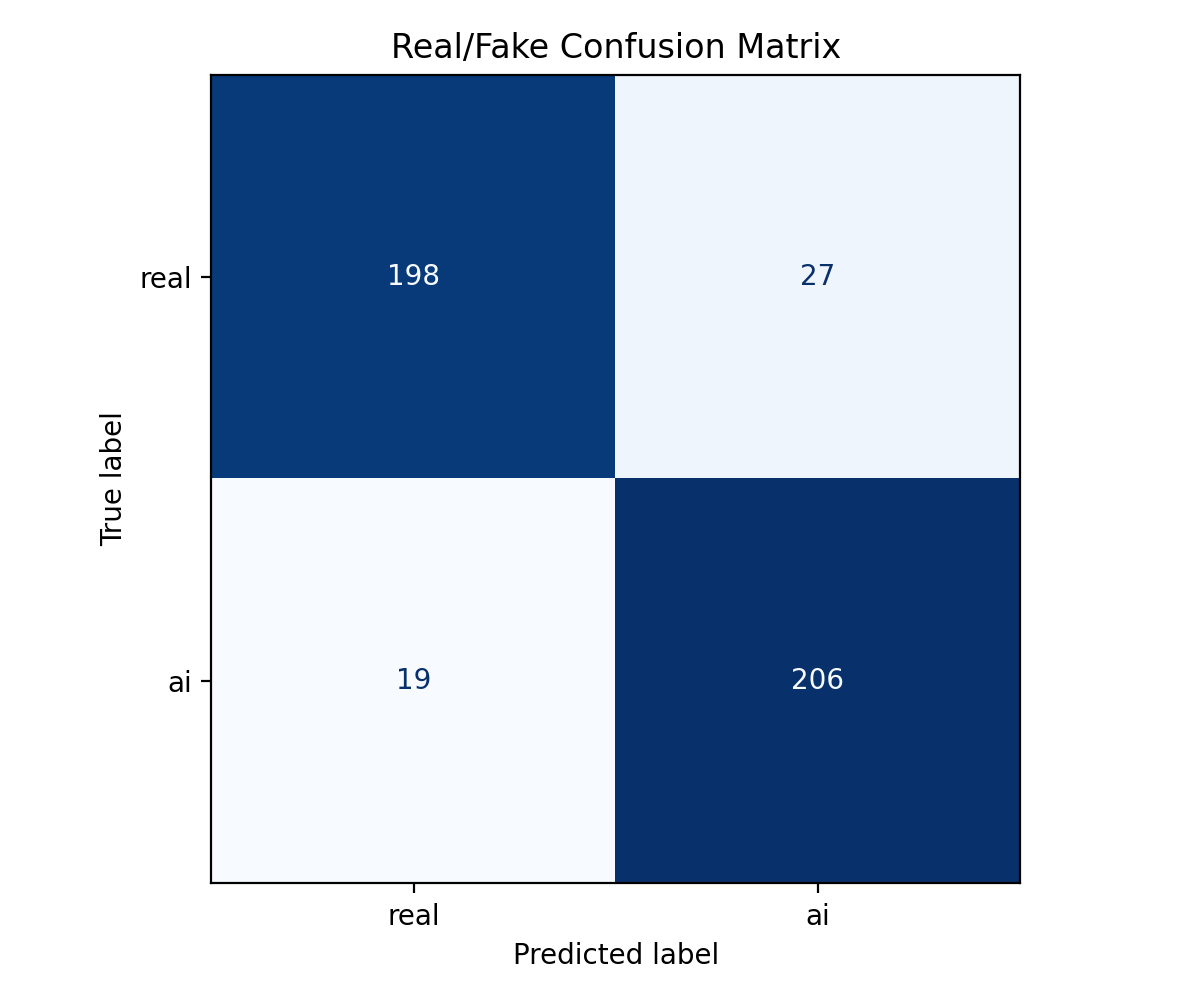

In [ ]:
show_evaluation_outputs("results/rgb_fake")

### Single-task Transformation Baseline

In [ ]:
# Train the transformation single-task baseline.
!python src/train_RGB.py \
  --task transform \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_transform.pt

Selected task: transform
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:10<00:00,  1.39it/s]
Train: {'loss': 1.0467873463176545, 'transform_acc': 0.46285714285714286}
Val:   {'loss': 0.8547235410743289, 'transform_acc': 0.62}
Val score: 0.6200
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_transform.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'loss': 0.6422365173839387, 'transform_acc': 0.6823809523809524}
Val:   {'loss': 0.6507781895664003, 'transform_acc': 0.7311111111111112}
Val score: 0.7311
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_transform.pt

Epoch 3/10
Training: 100% 66/66 [00:39<00:00,  1.65it/s]
Validation: 100% 15/15 [00:10<00:00,  1.40it/s]
Train: {'loss': 0.48102551028842017, 'transform_acc': 0.7780952380952381}
Val:   {'loss': 0.5937198723024792, 'transform_acc': 0.76}
Val score: 0.7600
Learni

In [ ]:
# Evaluate the transformation single-task baseline.
!python src/evaluate_RGB.py \
  --task transform \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_transform.pt \
  --output_dir results/rgb_transform \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: transform
Using device: cuda

Evaluation results
Transform accuracy:   0.8133
Transform F1 macro:   0.8116

Saved results in:
results/rgb_transform


Evaluation metrics


,Metric,Group,Value
0,transform_accuracy,-,0.8133
1,transform_f1_macro,-,0.8116



Transformation confusion matrix


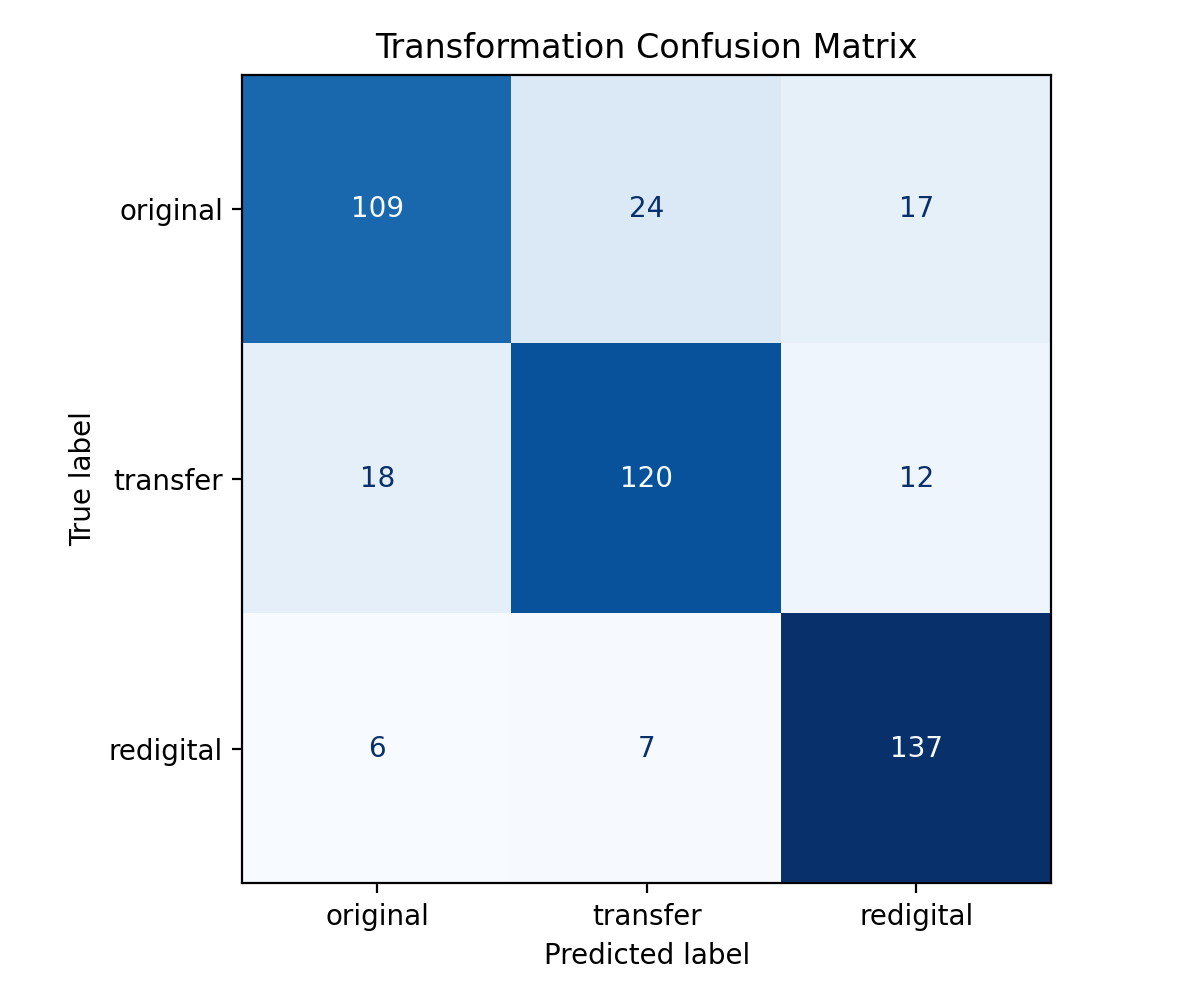

In [ ]:
show_evaluation_outputs("results/rgb_transform")

### Multi-task Baseline, Manual Weights 1.0 / 1.0

In [ ]:
# Train the joint RGB multi-task baseline with weights 1 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_1_1.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:09<00:00,  1.52it/s]
Train: {'loss': 1.3638698051089333, 'fake_acc': 0.8728571428571429, 'transform_acc': 0.4038095238095238}
Val:   {'loss': 1.0771654134326512, 'fake_acc': 0.8755555555555555, 'transform_acc': 0.6088888888888889}
Val score: 0.7422
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_1.pt

Epoch 2/10
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:09<00:00,  1.51it/s]
Train: {'loss': 0.7844145565941221, 'fake_acc': 0.9785714285714285, 'transform_acc': 0.6433333333333333}
Val:   {'loss': 0.9403924859894647, 'fake_acc': 0.8888888888888888, 'transform_acc': 0.68}
Val score: 0.7844
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_1.pt

Epoch 3/10
Training: 100% 66/66 [00:40<00:00,  1.65it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 0.5851

In [ ]:
# Evaluate the joint RGB multi-task baseline with weights 1 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_1.pt \
  --output_dir results/rgb_multitask_1_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9267
Fake F1 macro:        0.9266

Fake accuracy by transformation:
  original: 0.9267
  transfer: 0.9267
  redigital: 0.9267
Transform accuracy:   0.7933
Transform F1 macro:   0.7915

Saved results in:
results/rgb_multitask_1_1


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9267
1,fake_f1_macro,-,0.9266
2,fake_accuracy_by_transform,original,0.9267
3,fake_accuracy_by_transform,transfer,0.9267
4,fake_accuracy_by_transform,redigital,0.9267
5,transform_accuracy,-,0.7933
6,transform_f1_macro,-,0.7915



Real/Fake confusion matrix


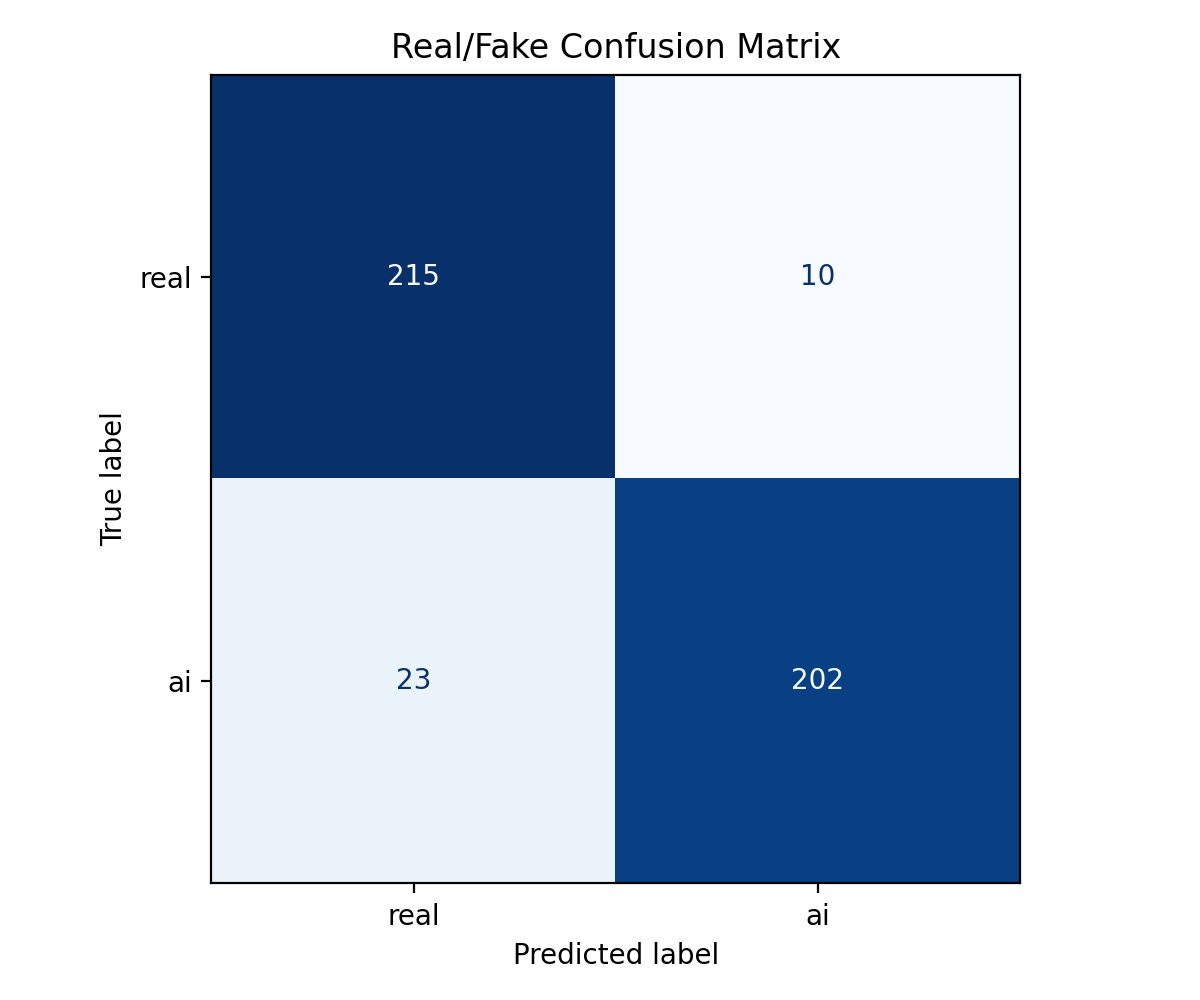


Transformation confusion matrix


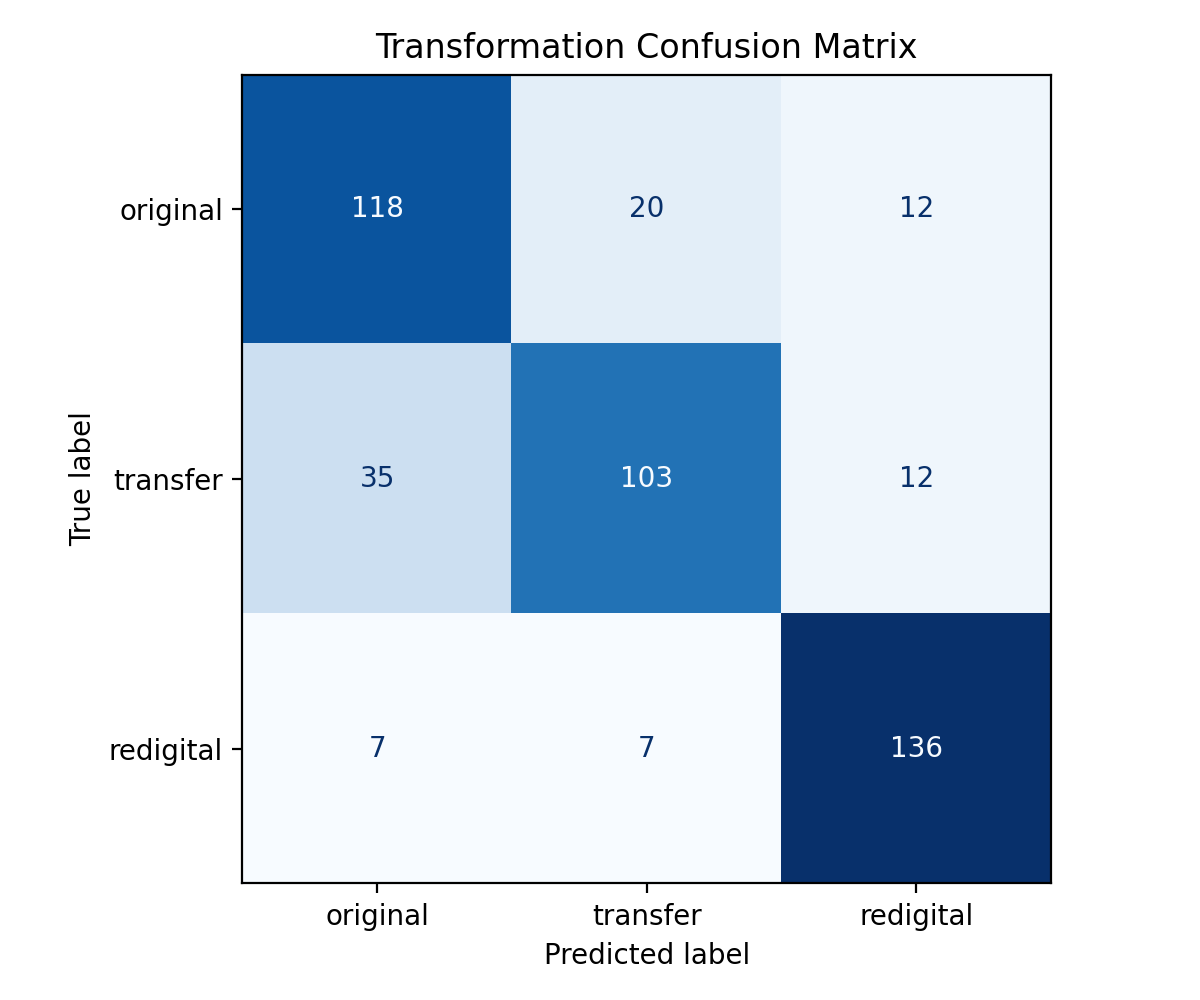

In [ ]:
show_evaluation_outputs("results/rgb_multitask_1_1")

### Multi-task Baseline, Manual Weights 1.0 / 2.0

In [ ]:
# Train the joint RGB multi-task baseline with weights 1 2.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 2.0 \
  --checkpoint_name best_rgb_multitask_1_2.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.37it/s]
Train: {'loss': 2.482335517519996, 'fake_acc': 0.8590476190476191, 'transform_acc': 0.43666666666666665}
Val:   {'loss': 2.04205621931288, 'fake_acc': 0.8711111111111111, 'transform_acc': 0.5977777777777777}
Val score: 0.7344
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_2.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:10<00:00,  1.40it/s]
Train: {'loss': 1.4879925396328881, 'fake_acc': 0.9595238095238096, 'transform_acc': 0.659047619047619}
Val:   {'loss': 1.5151270824008518, 'fake_acc': 0.9111111111111111, 'transform_acc': 0.7222222222222222}
Val score: 0.8167
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_2.pt

Epoch 3/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.38it/s]
Train: {'lo

In [ ]:
# Evaluate the joint RGB multi-task baseline with weights 1 2.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_2.pt \
  --output_dir results/rgb_multitask_1_2 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9222
Fake F1 macro:        0.9220

Fake accuracy by transformation:
  original: 0.9267
  transfer: 0.9267
  redigital: 0.9133
Transform accuracy:   0.7933
Transform F1 macro:   0.7931

Saved results in:
results/rgb_multitask_1_2


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9222
1,fake_f1_macro,-,0.9220
2,fake_accuracy_by_transform,original,0.9267
3,fake_accuracy_by_transform,transfer,0.9267
4,fake_accuracy_by_transform,redigital,0.9133
5,transform_accuracy,-,0.7933
6,transform_f1_macro,-,0.7931



Real/Fake confusion matrix


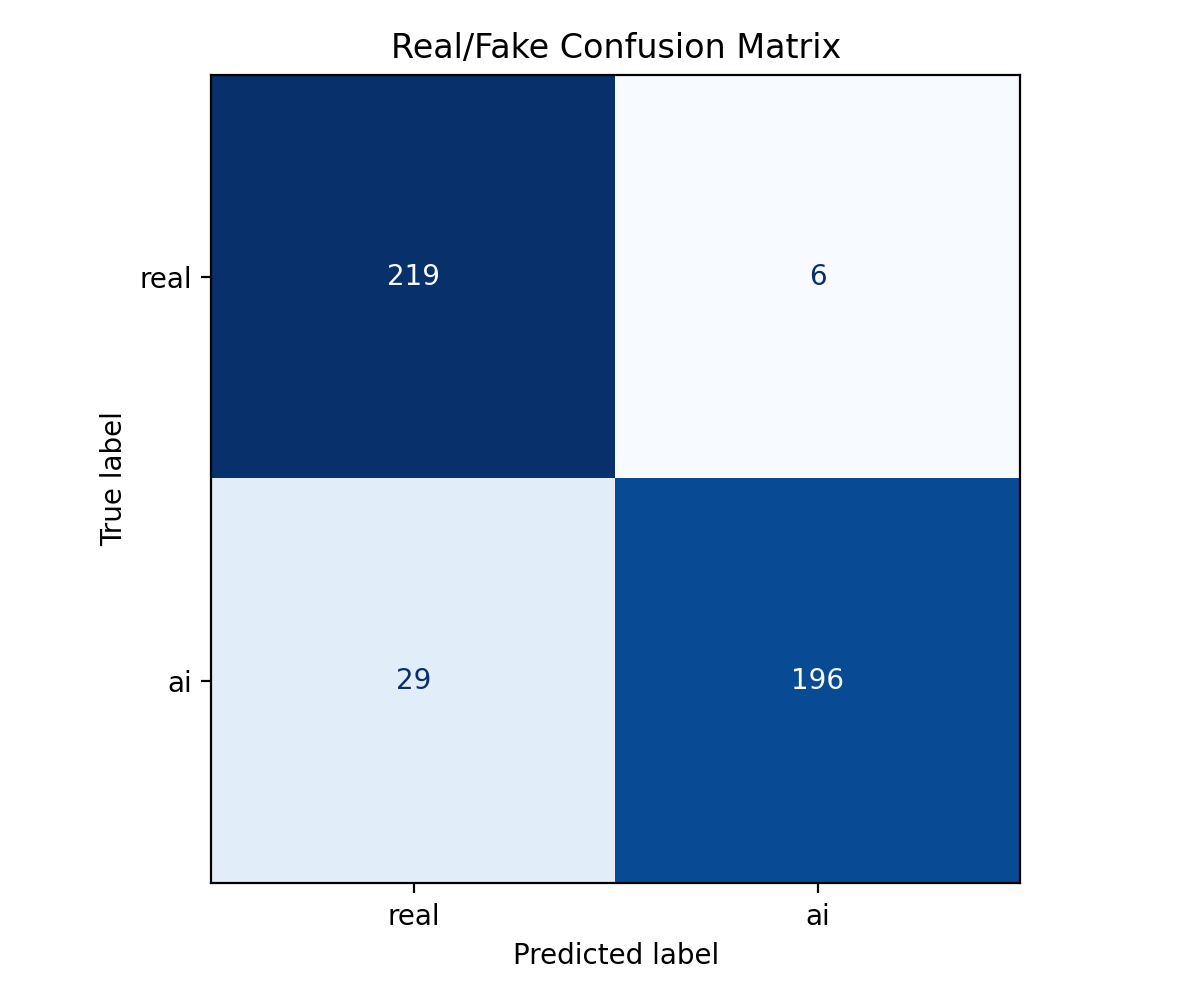


Transformation confusion matrix


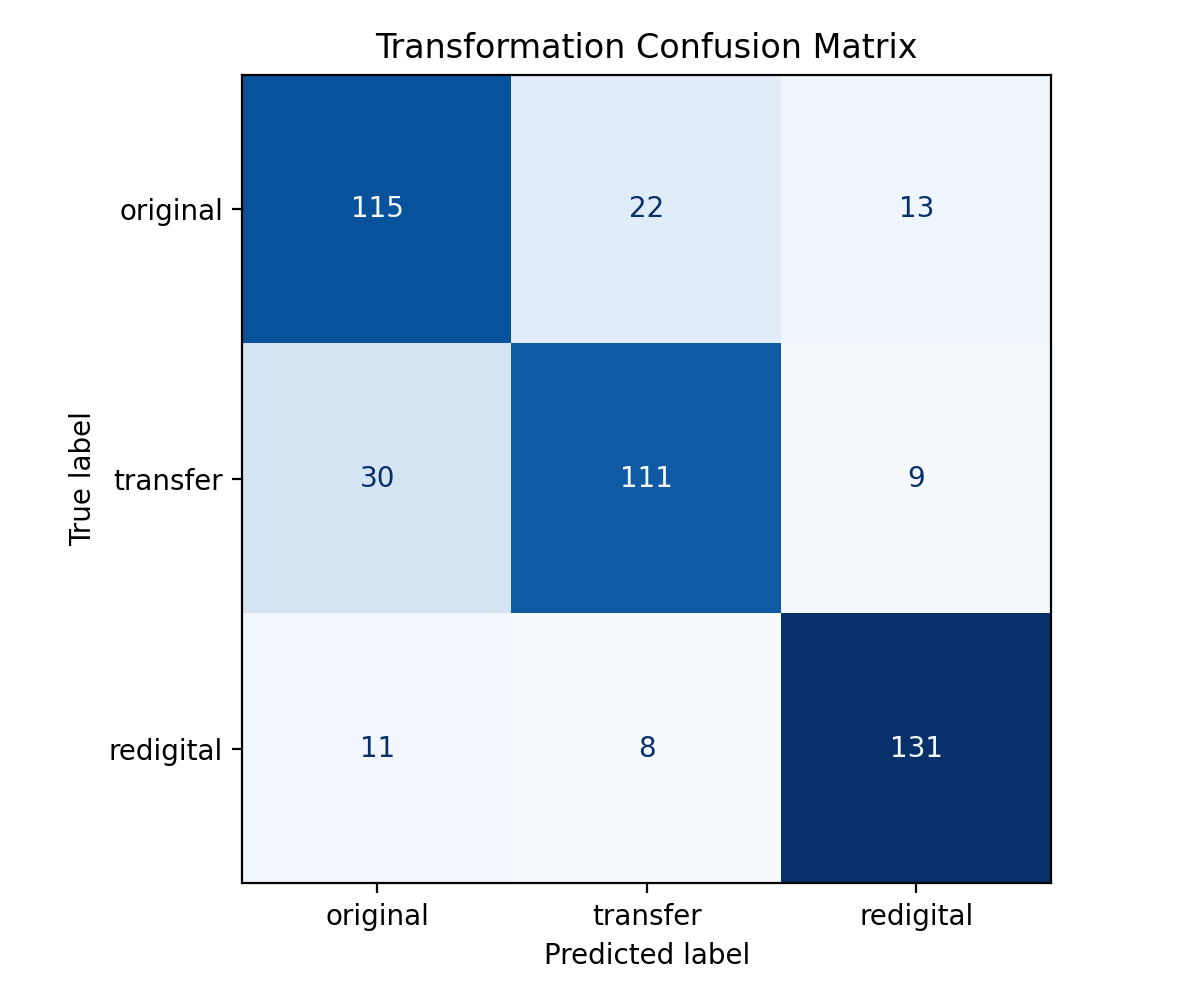

In [ ]:
show_evaluation_outputs("results/rgb_multitask_1_2")

### Multi-task Baseline, Manual Weights 2.0 / 1.0

In [ ]:
# Train the joint RGB multi-task baseline with weights 2 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 2.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_2_1.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:10<00:00,  1.37it/s]
Train: {'loss': 1.5948609218143281, 'fake_acc': 0.8809523809523809, 'transform_acc': 0.42952380952380953}
Val:   {'loss': 1.327419593864017, 'fake_acc': 0.9088888888888889, 'transform_acc': 0.5955555555555555}
Val score: 0.7522
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_2_1.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:10<00:00,  1.39it/s]
Train: {'loss': 0.8300882376943316, 'fake_acc': 0.9861904761904762, 'transform_acc': 0.6395238095238095}
Val:   {'loss': 1.1608510602845086, 'fake_acc': 0.9155555555555556, 'transform_acc': 0.6888888888888889}
Val score: 0.8022
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_2_1.pt

Epoch 3/10
Training: 100% 66/66 [00:40<00:00,  1.62it/s]
Validation: 100% 15/15 [00:10<00:00,  1.39it/s]
Train: {

In [ ]:
# Evaluate the joint RGB multi-task baseline with weights 2 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_2_1.pt \
  --output_dir results/rgb_multitask_2_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9289
Fake F1 macro:        0.9287

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9400
  redigital: 0.9133
Transform accuracy:   0.7822
Transform F1 macro:   0.7823

Saved results in:
results/rgb_multitask_2_1


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9289
1,fake_f1_macro,-,0.9287
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9400
4,fake_accuracy_by_transform,redigital,0.9133
5,transform_accuracy,-,0.7822
6,transform_f1_macro,-,0.7823



Real/Fake confusion matrix


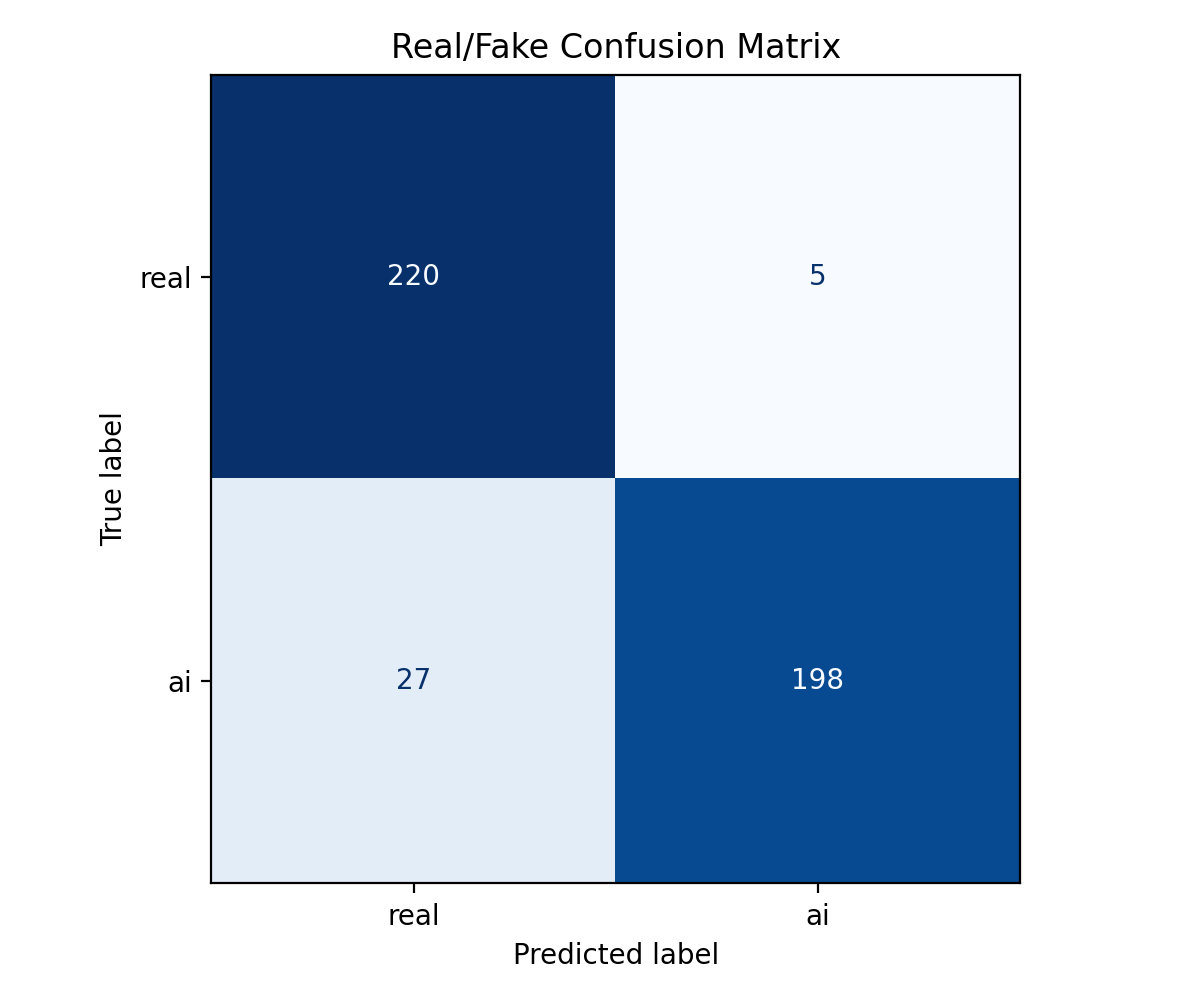


Transformation confusion matrix


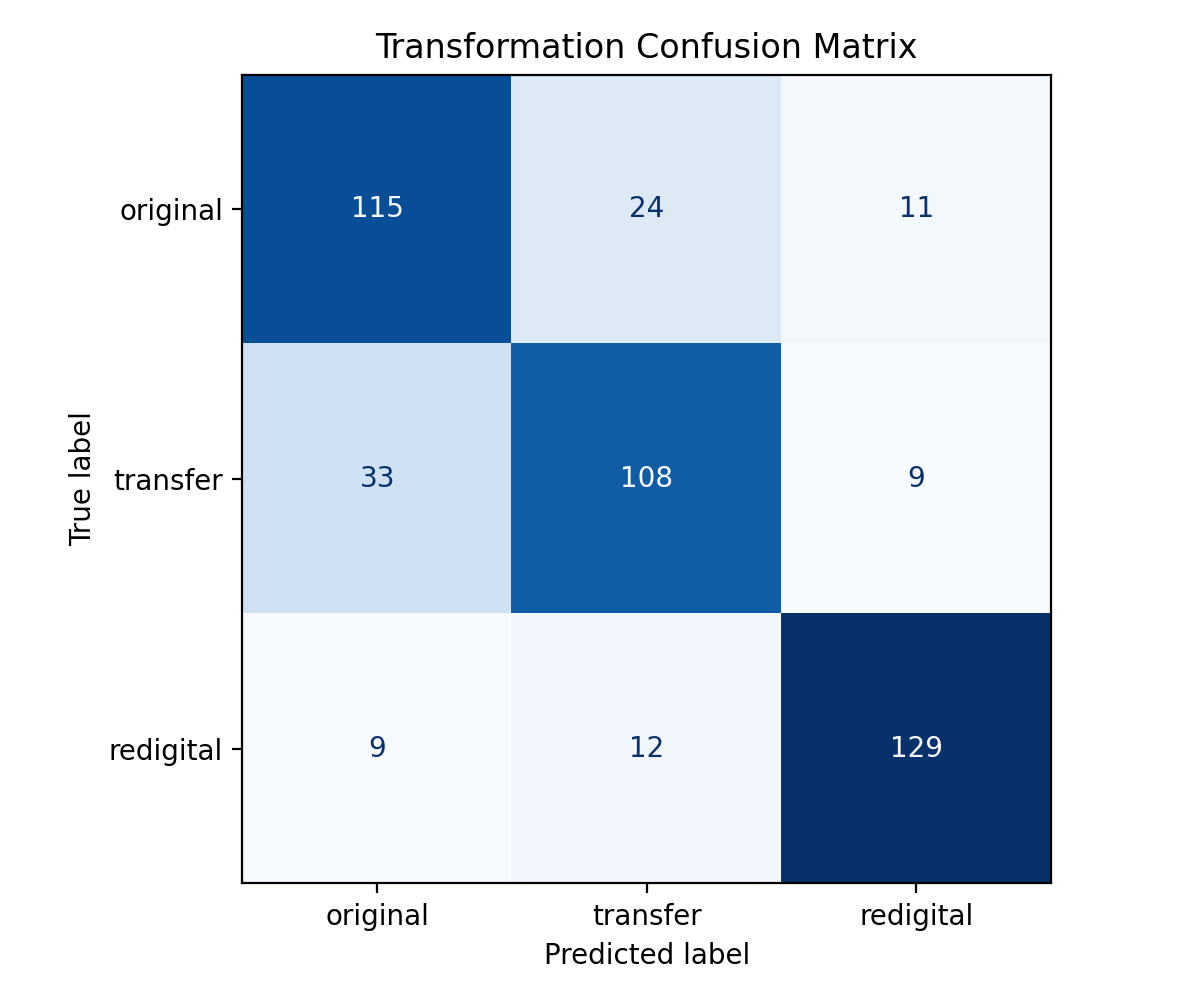

In [ ]:
show_evaluation_outputs("results/rgb_multitask_2_1")

### Multi-task Baseline, Learned Uncertainty Weighting

In [ ]:
# Train the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/train_RGB.py \
  --task multitask \
  --loss_weighting learned \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_multitask_learned_weights.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.65it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'loss': 1.3366669266564506, 'fake_acc': 0.8766666666666667, 'transform_acc': 0.44761904761904764, 'weight_fake': 1.00348094737891, 'weight_transform': 0.9978560642762617}
Val:   {'loss': 1.0414355701870388, 'fake_acc': 0.9, 'transform_acc': 0.6022222222222222, 'weight_fake': 1.0072664022445679, 'weight_transform': 0.9972468614578247}
Learned loss weights (train): fake=1.0035, transform=0.9979
Learned loss weights (val):   fake=1.0073, transform=0.9972
Val score: 0.7511
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_learned_weights.pt

Epoch 2/10
Training: 100% 66/66 [00:39<00:00,  1.65it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 0.7391409717287336, 'fake_acc': 0.98, 'transform_acc': 0.669047619047619, 'weight_fake': 1.0110305710272356, 'weight_transform': 1.0013211911374873

In [ ]:
# Evaluate the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_learned_weights.pt \
  --output_dir results/rgb_multitask_learned_weights \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9289
Fake F1 macro:        0.9289

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9467
  redigital: 0.9067
Transform accuracy:   0.7711
Transform F1 macro:   0.7708

Saved results in:
results/rgb_multitask_learned_weights


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9289
1,fake_f1_macro,-,0.9289
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9467
4,fake_accuracy_by_transform,redigital,0.9067
5,transform_accuracy,-,0.7711
6,transform_f1_macro,-,0.7708



Real/Fake confusion matrix


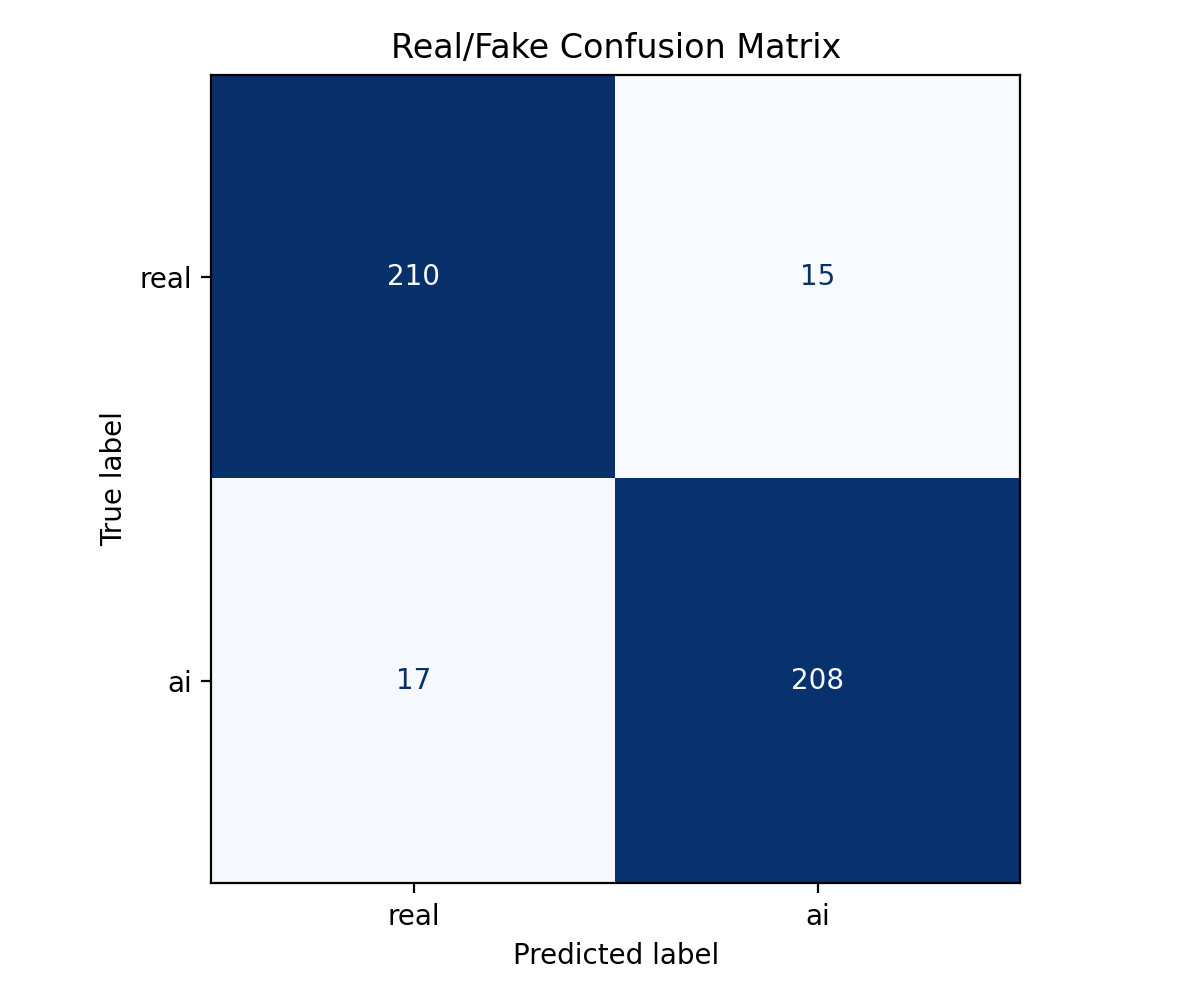


Transformation confusion matrix


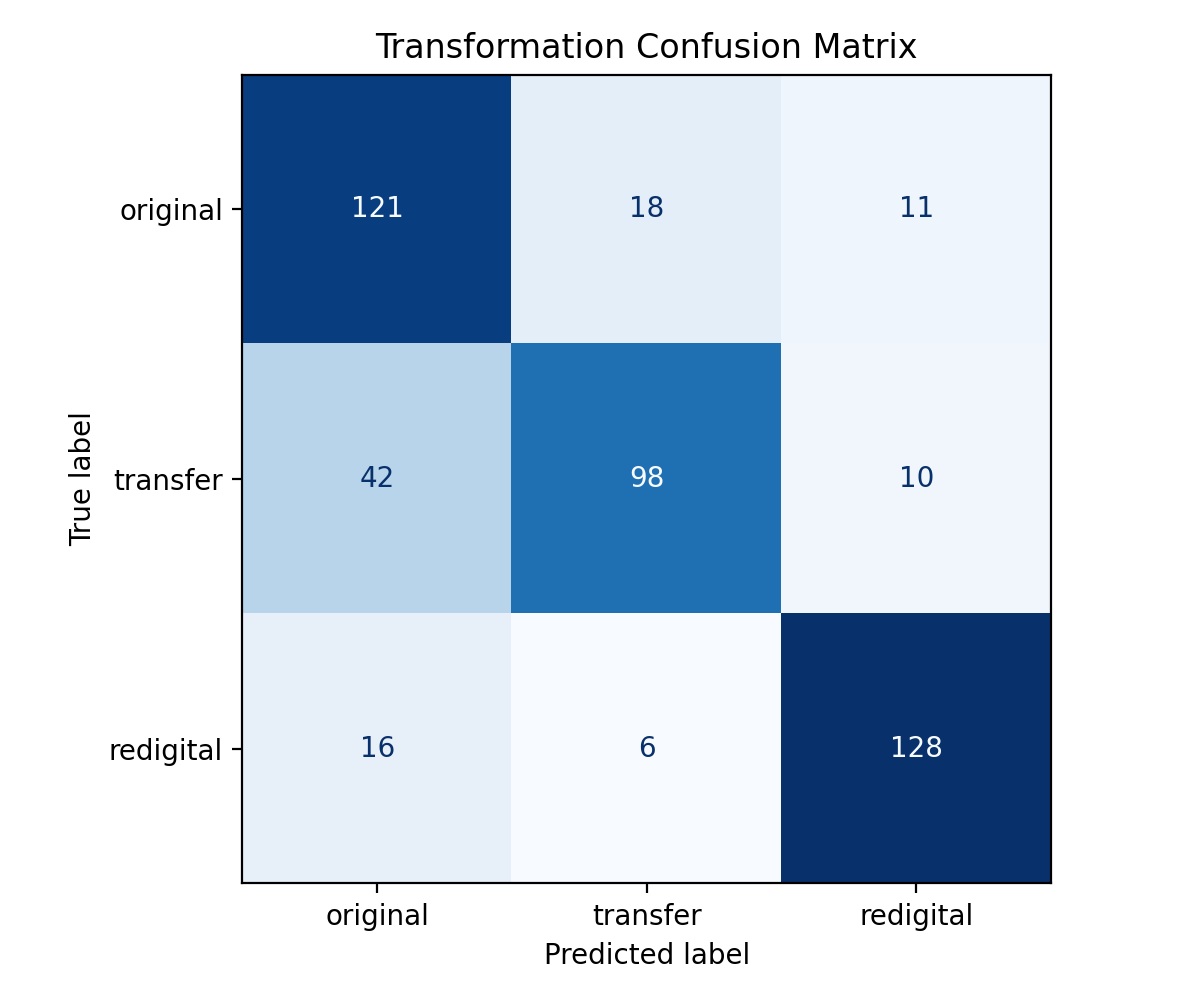

In [ ]:
show_evaluation_outputs("results/rgb_multitask_learned_weights")

## Results Comparison and Ablation Study

In [ ]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}

rows = []

for model_name, metrics_path in results.items():
    metrics_path = Path(metrics_path)

    if not metrics_path.exists():
        print(f"Missing file: {metrics_path}")
        continue

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    rows.append({
        "model": model_name,
        "fake_accuracy": metrics.get("fake_accuracy"),
        "fake_f1_macro": metrics.get("fake_f1_macro"),
        "transform_accuracy": metrics.get("transform_accuracy"),
        "transform_f1_macro": metrics.get("transform_f1_macro"),
        "fake_acc_original": metrics.get("fake_accuracy_by_transform", {}).get("original"),
        "fake_acc_transfer": metrics.get("fake_accuracy_by_transform", {}).get("transfer"),
        "fake_acc_redigital": metrics.get("fake_accuracy_by_transform", {}).get("redigital"),
    })

comparison_df = pd.DataFrame(rows)
comparison_df.sort_values(
    by=["fake_accuracy", "transform_accuracy"],
    ascending=False
)

,model,fake_accuracy,fake_f1_macro,transform_accuracy,transform_f1_macro,fake_acc_original,fake_acc_transfer,fake_acc_redigital
4,RGB multitask 2-1,0.928889,0.928719,0.782222,0.782252,0.933333,0.940000,0.913333
5,RGB multitask learned,0.928889,0.928887,0.771111,0.770779,0.933333,0.946667,0.906667
2,RGB multitask 1-1,0.926667,0.926605,0.793333,0.791475,0.926667,0.926667,0.926667
3,RGB multitask 1-2,0.922222,0.922019,0.793333,0.793069,0.926667,0.926667,0.913333
0,RGB fake-only,0.897778,0.897745,NaN,NaN,0.906667,0.906667,0.880000
1,RGB transform-only,NaN,NaN,0.813333,0.811583,NaN,NaN,NaN


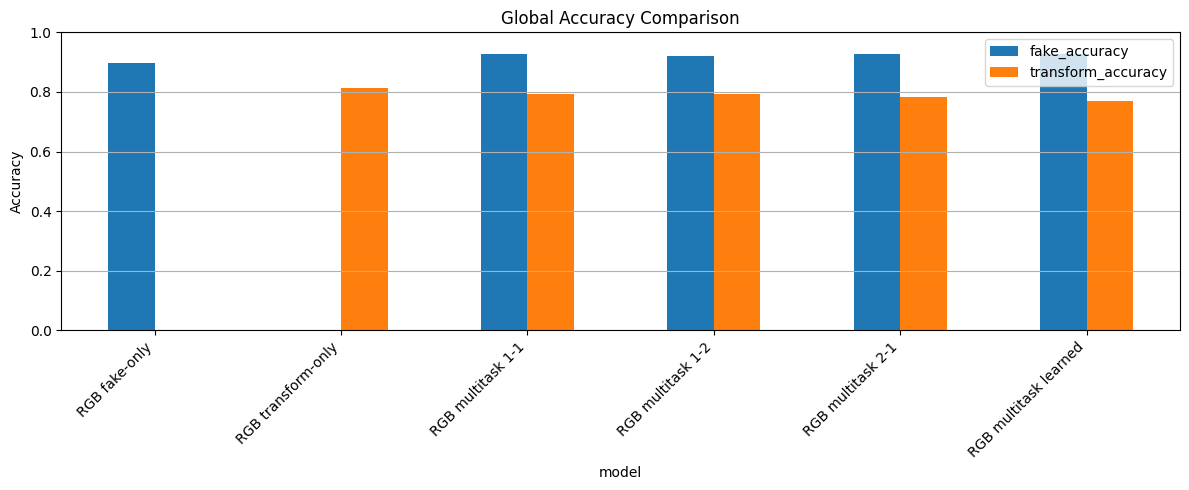

In [ ]:
# Global Accuracy Comparison

plot_df = comparison_df.set_index("model")

plot_df[["fake_accuracy", "transform_accuracy"]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Global Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

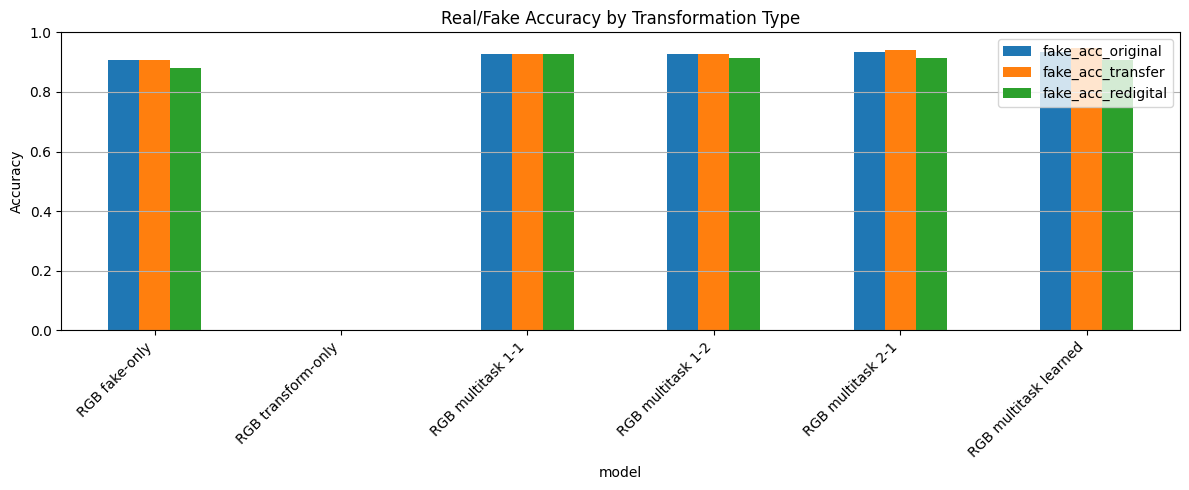

In [ ]:
# Real/Fake Accuracy by Transformation Type
plot_df[[
    "fake_acc_original",
    "fake_acc_transfer",
    "fake_acc_redigital",
]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Real/Fake Accuracy by Transformation Type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#FREQUENCY


**TRAIN**

In [ ]:
# Frequency multi-task using weights 1.0 / 1.0
!python src/train_freq.py \
  --train_csv        {TRAIN_CSV} \
  --val_csv          {VAL_CSV} \
  --image_root       {IMAGE_ROOT} \
  --epochs           {EPOCHS} \
  --batch_size       {BATCH_SIZE} \
  --image_size       {IMAGE_SIZE} \
  --num_workers      {NUM_WORKERS} \
  --lambda_fake      1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name  best_freq_multitask_1_1.pt

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 188MB/s]

Epoch 1/10
Training freq: 100% 66/66 [00:44<00:00,  1.47it/s]
Validation freq: 100% 15/15 [00:12<00:00,  1.24it/s]
Train: {'loss': 1.4387780284881593, 'fake_acc': 0.8238095238095238, 'transform_acc': 0.4357142857142857}
Val:   {'loss': 1.2412046432495116, 'fake_acc': 0.9088888888888889, 'transform_acc': 0.45111111111111113}
Val score: 0.6800
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_freq_multitask_1_1.pt

Epoch 2/10
Training freq: 100% 66/66 [00:44<00:00,  1.50it/s]
Validation freq: 100% 15/15 [00:11<00:00,  1.33it/s]
Train: {'loss': 0.8690021456990923, 'fake_acc': 0.9676190476190476, 'transform_acc': 0.6038095238095238}
Val:   {'loss': 0.9780212736129761, 'fake_acc': 0.9222222222222223, 'transform_acc': 0.6377777777777778}
Val score: 0.7800
Learning rate: 0.000100
Saved b

**EVALUATE**

In [ ]:
!python src/evaluate_freq.py \
  --csv_path    {TEST_CSV} \
  --image_root  {IMAGE_ROOT} \
  --checkpoint  checkpoints/best_freq_multitask_1_1.pt \
  --output_dir  results/freq_multitask_1_1 \
  --batch_size  {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Using device: cuda

Evaluation results — Frequency model
Fake accuracy:        0.9200
Fake F1 macro:        0.9198
Transform accuracy:   0.7978
Transform F1 macro:   0.7961

Fake accuracy by transformation:
  original: 0.9267
  transfer: 0.9200
  redigital: 0.9133

Saved results in: results/freq_multitask_1_1


**RESULTS**

Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9200
1,fake_f1_macro,-,0.9198
2,transform_accuracy,-,0.7978
3,transform_f1_macro,-,0.7961
4,fake_accuracy_by_transform,original,0.9267
5,fake_accuracy_by_transform,transfer,0.9200
6,fake_accuracy_by_transform,redigital,0.9133



Real/Fake confusion matrix


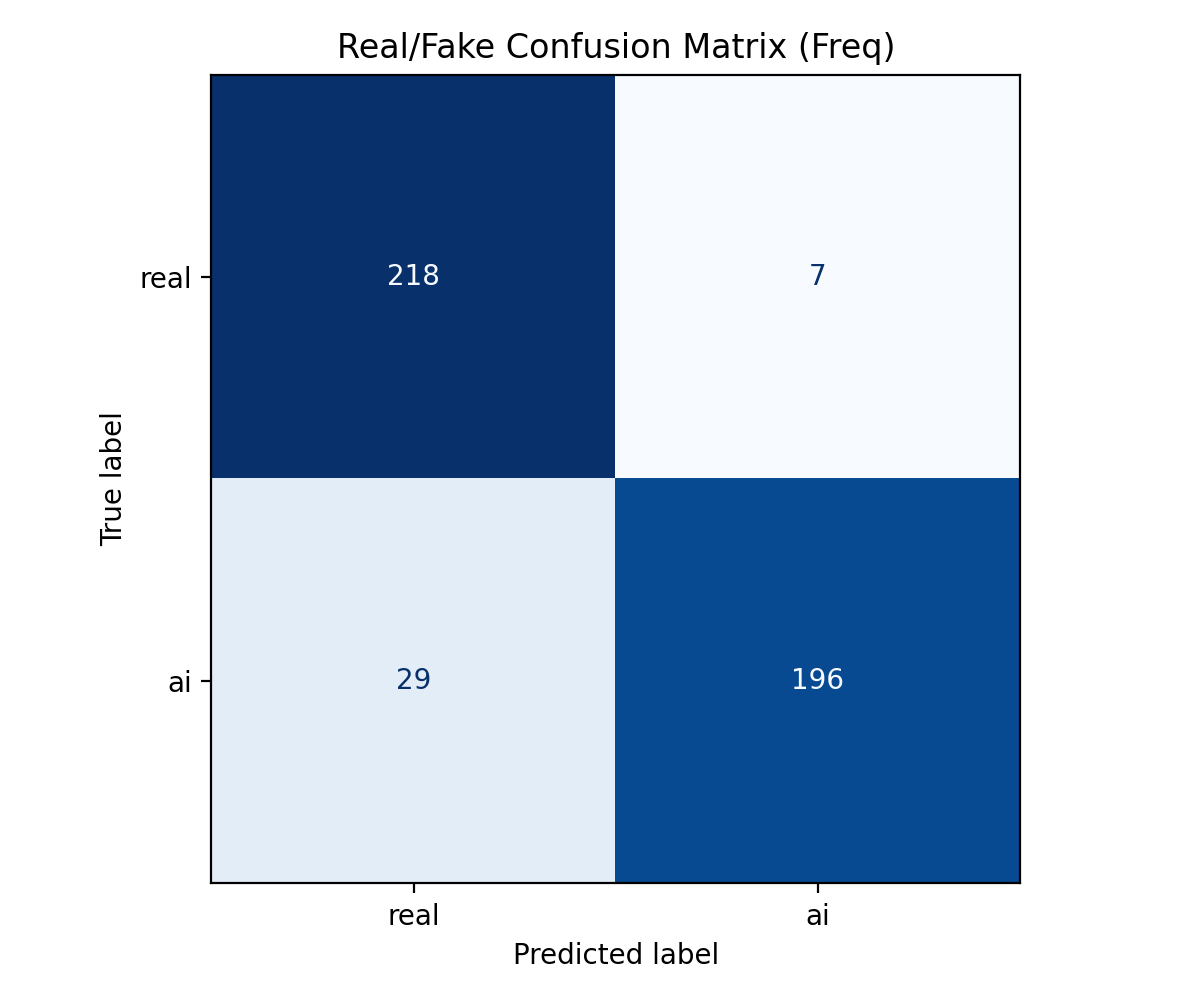


Transformation confusion matrix


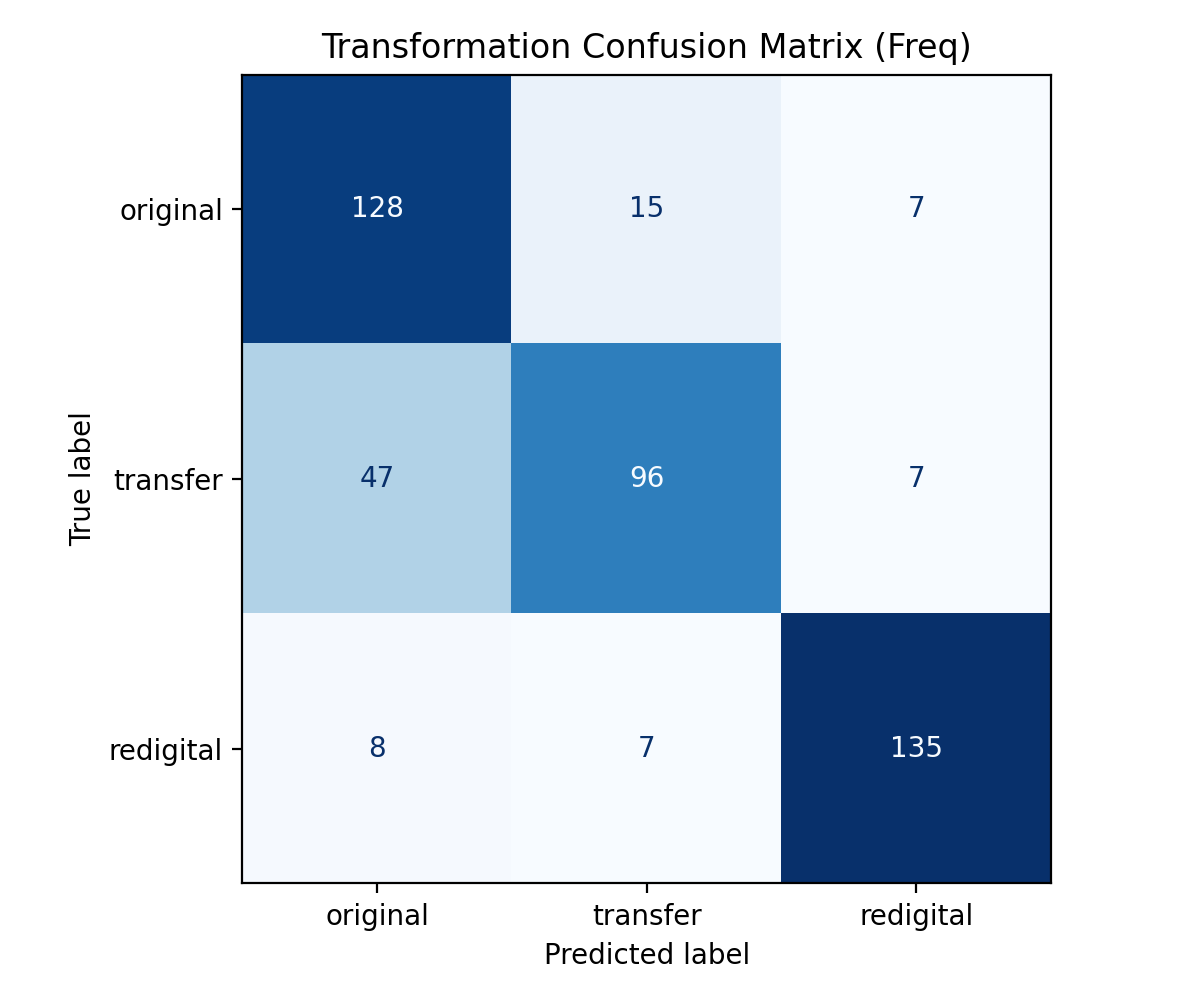

In [ ]:
show_evaluation_outputs("results/freq_multitask_1_1")

**COMPARISON**

In [ ]:
results["Freq multitask 1-1"] = "results/freq_multitask_1_1/metrics.json"

NameError: name 'results' is not defined

#DEPTH

In [ ]:
!find /content -name "real_006970.jpg"

##Depth map generation

###first small debug

In [ ]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV}\
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small \
  --max_images 5

###full depth map generation

In [ ]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small

##copy of depth maph in local so colab doesn't need to go on drive every time

In [ ]:
DRIVE_DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"
LOCAL_DEPTH_ROOT = "/content/depth_maps"

!mkdir -p "{LOCAL_DEPTH_ROOT}"
!rsync -a --info=progress2 "{DRIVE_DEPTH_ROOT}/" "{LOCAL_DEPTH_ROOT}/"

DEPTH_ROOT = LOCAL_DEPTH_ROOT

print("Depth maps will be loaded from:", DEPTH_ROOT)

##First try with depth only

In [ ]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting \
  --no_edge

The edge-consistency branch introduces additional geometric information, but also increases model complexity. This leads to mild overfitting and a small decrease in real/fake validation accuracy, although transformation classification slightly improves.
We should use only depth without edge

##Evaluate RGB+Depth no edge

saves on drive not only local

In [ ]:
DRIVE_CKPT_ROOT = "/content/drive/MyDrive/CV_Project/checkpoints"

!mkdir -p "{DRIVE_CKPT_ROOT}"
!cp /content/REPO/checkpoints/*.pt "{DRIVE_CKPT_ROOT}/"

!ls "{DRIVE_CKPT_ROOT}"

best_depth_frequency_uncertainty.pt  best_depth_uncertainty.pt


puts again in local

In [ ]:
DRIVE_CKPT_ROOT = "/content/drive/MyDrive/CV_Project/checkpoints"
LOCAL_CKPT_ROOT = "/content/REPO/checkpoints"

!mkdir -p "{LOCAL_CKPT_ROOT}"
!cp "{DRIVE_CKPT_ROOT}"/*.pt "{LOCAL_CKPT_ROOT}/"

!ls "{LOCAL_CKPT_ROOT}"

In [ ]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/depth_only \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge

In [ ]:
show_evaluation_outputs("results/depth_only")

Metrics file not found: results/depth_only/metrics.json


##grad-cam

real

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/gradcam_depth_only \
  --task fake \
  --target predicted \
  --max_images 2 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge \
  --fake_filter 0 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/gradcam_depth_only \
  --task fake \
  --target predicted \
  --max_images 2 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge \
  --fake_filter 1 \
  --shuffle

In [ ]:
from IPython.display import Image, display
from pathlib import Path

gradcam_dir = Path("results/gradcam_depth_only")

for img_path in sorted(gradcam_dir.glob("*.png")):
    print(img_path.name)
    display(Image(filename=str(img_path)))

transform

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/gradcam_transform \
  --task transform \
  --target predicted \
  --max_images 2 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge \
  --transform_filter 0 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/gradcam_transform \
  --task transform \
  --target predicted \
  --max_images 2 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge \
  --transform_filter 1 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/gradcam_transform \
  --task transform \
  --target predicted \
  --max_images 2 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge \
  --transform_filter 2 \
  --shuffle

In [ ]:
from IPython.display import Image, display
from pathlib import Path

gradcam_dir = Path("results/gradcam_transform")

for img_path in sorted(gradcam_dir.glob("*.png")):
    print(img_path.name)
    display(Image(filename=str(img_path)))

##Second try with also edge consistency

In [ ]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_edge_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

#Evaluate RGB+Depth+edge

In [ ]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/depth_edge \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

In [ ]:
show_evaluation_outputs("results/depth_edge")

Metrics file not found: results/depth_edge/metrics.json


#DEPTH+FREQUENCY

In [ ]:
print(EPOCHS)
print(type(EPOCHS))

!echo {EPOCHS}

10
<class 'int'>
10


In [ ]:
!python src/train_depth_frequency.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_frequency_uncertainty.pt \
   --checkpoint checkpoints/best_depth_frequency_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

Using device: cuda

Epoch 1/10
Training RGB+Depth+Frequency: 100% 66/66 [01:40<00:00,  1.52s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:26<00:00,  1.79s/it]
Train: {'loss': 1.4183925043968928, 'fake_acc': 0.8423809523809523, 'transform_acc': 0.43476190476190474, 'weight_fake': 1.0035364122101755, 'weight_transform': 0.9973158646713604}
Val:   {'loss': 1.0923698825306363, 'fake_acc': 0.9, 'transform_acc': 0.5711111111111111, 'weight_fake': 1.0074642896652222, 'weight_transform': 0.996420681476593}
Val score: 0.7356
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_depth_frequency_uncertainty.pt

Epoch 2/10
Training RGB+Depth+Frequency: 100% 66/66 [01:37<00:00,  1.47s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:25<00:00,  1.73s/it]
Train: {'loss': 0.8377851785932269, 'fake_acc': 0.9619047619047619, 'transform_acc': 0.6061904761904762, 'weight_fake': 1.011455718315009, 'weight_transform': 1.0011015669866041}
Val:   {'loss': 1.0683053980933295, 'fake_acc': 0.